In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('heart.csv')

In [4]:
df.shape

(1025, 14)

In [5]:
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [7]:
df.describe()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [8]:
import matplotlib.pyplot as plt

<Axes: xlabel='target'>

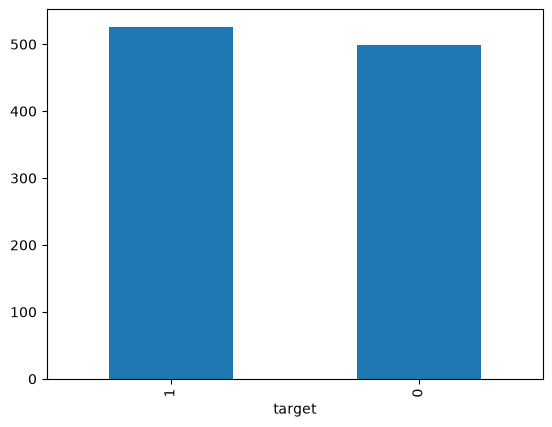

In [9]:
df['target'].value_counts().plot(kind='bar')

In [10]:
type(df)

pandas.DataFrame

In [11]:
type(df['target'])

pandas.Series

In [12]:
df['target'].value_counts()


target
1    526
0    499
Name: count, dtype: int64

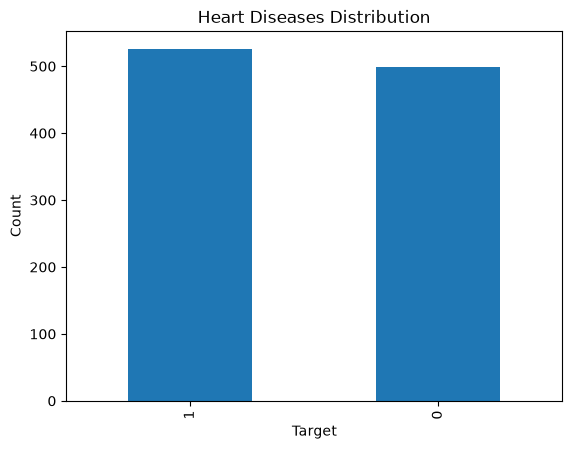

In [13]:
df['target'].value_counts().plot(kind='bar')
plt.title('Heart Diseases Distribution')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

## EDA - Finding 1: Target Distribution
- 526 patients have heart disease (target = 1)
- 499 patients have no heart disease (target = 0)
- Dataset is nearly balanced (51.3% vs 48.7%)
- This is ideal for ML — model cannot cheat by predicting one class always
- Both classes are well represented, so model will learn real patterns

In [14]:
import sys

In [15]:
!{sys.executable} -m pip install seaborn 


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [17]:
df = pd.read_csv('heart.csv')


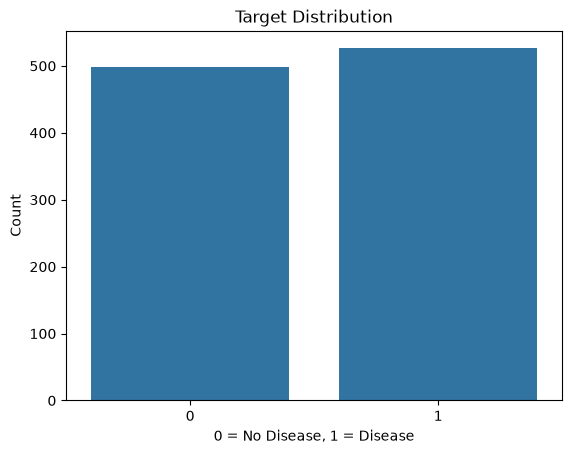

In [18]:
sns.countplot(x=df['target'])
plt.title('Target Distribution')
plt.xlabel('0 = No Disease, 1 = Disease')
plt.ylabel('Count')
plt.show()

## Univariate Analysis — Finding 1: Target Column
- 1 (disease) = 526 patients
- 0 (no disease) = 499 patients  
- Dataset is balanced — 51.3% vs 48.7%
- Model cannot cheat by predicting one class always
- Both classes well represented = model will learn real patterns

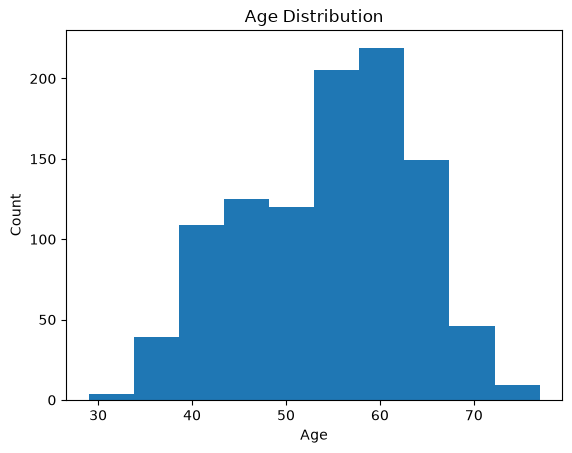

In [19]:
plt.hist(df['age'], bins=10)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [20]:
print(df['age'].min())
print(df['age'].max())
print(df['age'].mean())
print(df['age'].skew())

29
77
54.43414634146342
-0.24886590174584555


126
564
246.0
1.0740727783354815


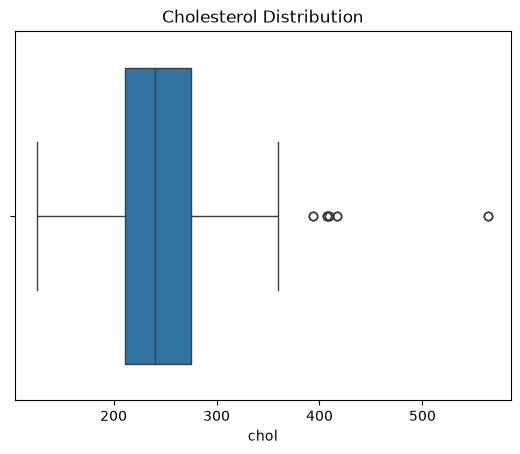

In [21]:
print(df['chol'].min())
print(df['chol'].max())
print(df['chol'].mean())
print(df['chol'].skew())

sns.boxplot(x=df['chol'])
plt.title('Cholesterol Distribution')
plt.show()

## Univariate Analysis — Finding 3: Cholesterol Column
- Range: 126 to 564
- Mean: 246 (already above high threshold of 240)
- Skew: 1.07 (severe positive skew)
- Outliers present — value of 564 is nearly 3x normal cholesterol
- ACTION NEEDED: transformation required during preprocessing
- Possible fix: log transformation or outlier removal

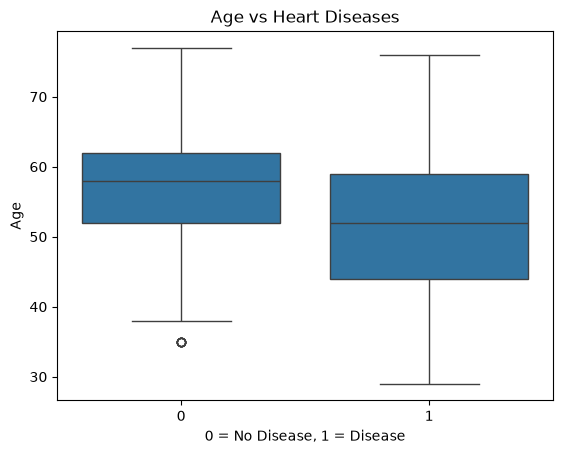

In [23]:
sns.boxplot(x=df['target'], y=df['age'])
plt.title('Age vs Heart Diseases')
plt.xlabel('0 = No Disease, 1 = Disease')
plt.ylabel('Age')
plt.show()

## Bivariate Analysis — Finding 1: Age vs Target
- No disease patients (0) have higher median age (~58)
- Disease patients (1) have lower median age (~52)
- Counter-intuitive finding — younger patients show more disease
- One outlier in group 0 (unusually young no-disease patient)
- Age is a useful feature but not the strongest predictor


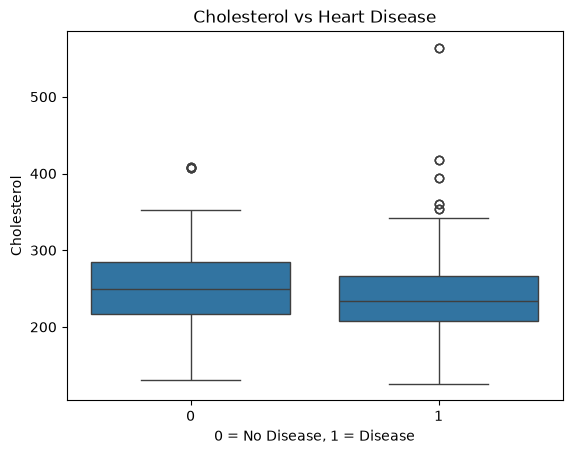

In [24]:
sns.boxplot(x=df['target'], y=df['chol'])
plt.title('Cholesterol vs Heart Disease')
plt.xlabel('0 = No Disease, 1 = Disease')
plt.ylabel('Cholesterol')
plt.show()

## Bivariate Analysis — Finding 2: Cholesterol vs Target
- No disease patients (0) have slightly higher median cholesterol
- Counter-intuitive — cholesterol not a strong predictor here
- High overlap between both groups
- Outliers present in both groups (especially the 564 value)
- Cholesterol alone won't strongly predict heart disease

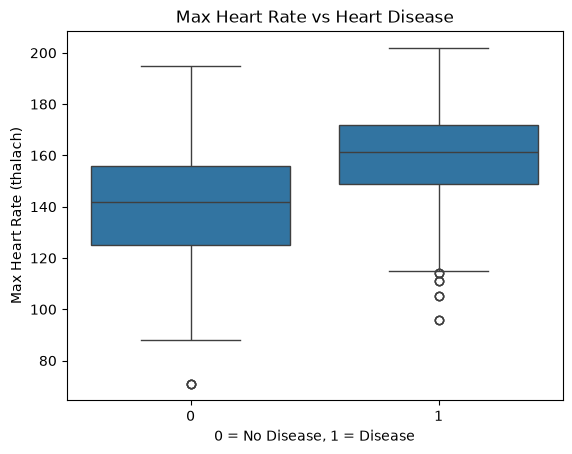

In [25]:
sns.boxplot(x=df['target'], y=df['thalach'])
plt.title('Max Heart Rate vs Heart Disease')
plt.xlabel('0 = No Disease, 1 = Disease')
plt.ylabel('Max Heart Rate (thalach)')
plt.show()

In [26]:
print(df.groupby('target')['thalach'].median())


target
0    142.0
1    161.5
Name: thalach, dtype: float64


## Bivariate Analysis — Finding 3: Thalach vs Target
- Disease patients (1) median thalach = 161
- No disease patients (0) median thalach = 142
- Disease patients achieve higher max heart rate
- Connected to age finding — disease patients are younger
- Thalach is a strong predictor — significant difference between groups

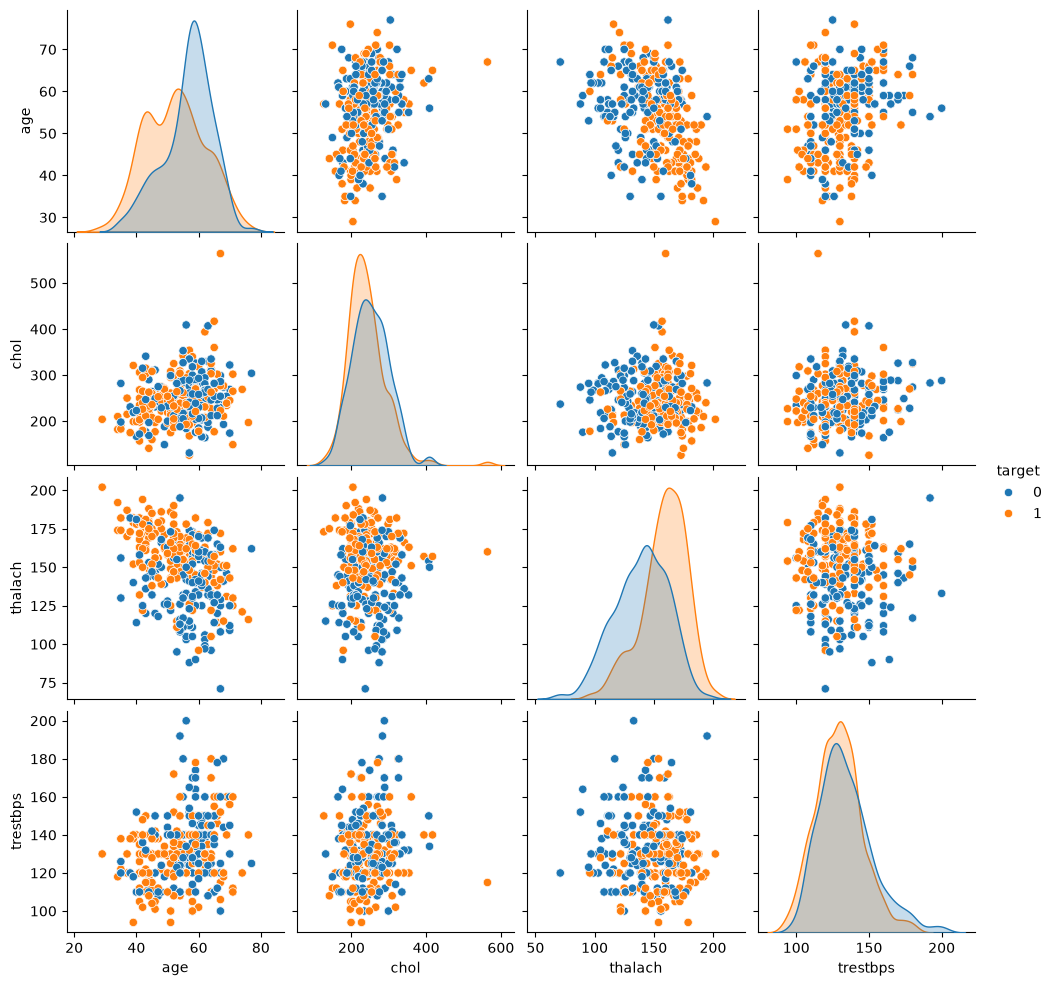

In [27]:
sns.pairplot(df[['age','chol','thalach','trestbps','target']], 
             hue='target')
plt.show()

## Bivariate Analysis — Finding 4: Pairplot
- No single pair of features perfectly separates disease from no disease
- Colors largely overlap across all plots
- Confirms that model needs ALL features combined, not just one or two
- thalach shows the most separation compared to other features

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('target', axis=1)  # Separate features and target
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)  # Split

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (820, 13)
Testing size: (205, 13)


In [30]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((820, 13), (205, 13), (820,), (205,))

In [31]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [33]:
scaler.fit(X_train)
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [34]:
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
import numpy as np
print("Mean after scaling:", np.round(X_train_scaled.mean(), 5))
print("Std after scaling:", np.round(X_train_scaled.std(), 5))

Mean after scaling: 0.0
Std after scaling: 1.0


In [36]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression() # create the model
model.fit(X_train_scaled, y_train) # train the model


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [37]:
y_pred = model.predict(X_test_scaled) # predict on test data
print(y_pred)


[1 1 0 1 0 1 0 0 1 0 1 0 1 1 0 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1 1 1 1 1 1 1 1
 0 1 1 0 0 1 0 0 0 0 0 1 0 1 0 1 0 1 1 0 0 1 1 1 0 0 0 0 0 1 1 0 1 1 0 0 1
 1 1 0 1 1 1 0 0 0 0 1 0 1 0 0 1 0 0 1 1 1 1 1 0 0 0 0 0 1 1 0 1 0 1 0 1 1
 1 1 0 1 1 1 1 1 0 0 1 0 0 0 0 1 1 1 1 1 0 1 0 0 1 0 1 1 1 1 1 1 0 1 1 1 1
 1 0 1 0 1 1 0 0 1 1 0 0 1 1 0 0 0 0 0 0 0 1 0 1 1 0 1 1 1 0 1 1 1 0 1 1 1
 1 1 1 1 1 1 1 1 1 0 0 1 0 1 1 1 1 1 0 0]


In [38]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.7951219512195122
